# Yahoo Answers Topic Classification - TF-IDF + LinearSVC

Notebook này train mô hình phân loại **10 topic Yahoo Answers** từ file:

`yahoo_answers_csv.tgz`

Mô hình dùng:
- `TfidfVectorizer`
- `LinearSVC`

Lưu ý: TF-IDF + LinearSVC chạy chủ yếu bằng **CPU + RAM**, GPU T4 gần như không giúp nhiều.  
Notebook có option `USE_ALL_DATA` để train toàn bộ hoặc sample mỗi topic cho nhẹ.

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Cấu hình đường dẫn và tham số

Sửa `TGZ_PATH` cho đúng vị trí file `yahoo_answers_csv.tgz` trong Drive của bạn.

- `USE_ALL_DATA = False`: lấy đủ 10 topic nhưng chỉ sample mỗi topic để tránh crash RAM.
- `USE_ALL_DATA = True`: train toàn bộ 1.400.000 dòng train.

In [2]:
import os
import re
import html
import tarfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings("ignore")

# ===== SỬA ĐƯỜNG DẪN NÀY CHO ĐÚNG FILE TRONG DRIVE =====
TGZ_PATH = "/content/drive/MyDrive/TrainTopic/yahoo_answers_csv.tgz"

# Thư mục giải nén tạm trên Colab
EXTRACT_DIR = "/content/yahoo_answers_extracted"

# Thư mục lưu model, report, hình
PROJECT_DIR = "/content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All"
MODEL_DIR = f"{PROJECT_DIR}/model"
REPORT_DIR = f"{PROJECT_DIR}/reports"
FIG_DIR = f"{PROJECT_DIR}/figures"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ===== CHẾ ĐỘ TRAIN =====
# False: lấy đủ 10 topic nhưng sample mỗi topic, khuyên dùng để tránh crash RAM
# True : train full 1.4 triệu dòng, có thể rất nặng
USE_ALL_DATA = False

# Nếu USE_ALL_DATA=False, mỗi topic lấy bao nhiêu dòng train
SAMPLE_PER_TOPIC = 80000   # Có thể đổi 50000 nếu RAM đủ

# Cấu hình TF-IDF
MAX_FEATURES = 50000
NGRAM_RANGE = (1, 2)
MIN_DF = 5
MAX_DF = 0.9

RANDOM_STATE = 42

print("TGZ_PATH:", TGZ_PATH)
print("PROJECT_DIR:", PROJECT_DIR)
print("File exists:", os.path.exists(TGZ_PATH))

TGZ_PATH: /content/drive/MyDrive/TrainTopic/yahoo_answers_csv.tgz
PROJECT_DIR: /content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All
File exists: True


## 3. Giải nén file `.tgz`

In [3]:
if not os.path.exists(TGZ_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy file: {TGZ_PATH}\n"
        "Hãy upload yahoo_answers_csv.tgz lên Drive và sửa TGZ_PATH cho đúng."
    )

os.makedirs(EXTRACT_DIR, exist_ok=True)

with tarfile.open(TGZ_PATH, "r:gz") as tar:
    tar.extractall(EXTRACT_DIR)

# Tìm thư mục chứa train.csv
candidate_dirs = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if "train.csv" in files and "test.csv" in files and "classes.txt" in files:
        candidate_dirs.append(root)

if not candidate_dirs:
    raise FileNotFoundError("Không tìm thấy train.csv, test.csv, classes.txt sau khi giải nén.")

DATA_DIR = candidate_dirs[0]

print("DATA_DIR:", DATA_DIR)
print("Files:", os.listdir(DATA_DIR))

DATA_DIR: /content/yahoo_answers_extracted/yahoo_answers_csv
Files: ['readme.txt', 'classes.txt', 'test.csv', 'train.csv']


## 4. Đọc classes.txt, train.csv, test.csv

In [4]:
columns = ["label", "question_title", "question_content", "best_answer"]

class_path = f"{DATA_DIR}/classes.txt"
train_path = f"{DATA_DIR}/train.csv"
test_path = f"{DATA_DIR}/test.csv"

with open(class_path, "r", encoding="utf-8", errors="ignore") as f:
    yahoo_class_names = [line.strip() for line in f.readlines() if line.strip()]

print("Yahoo topics:")
for i, name in enumerate(yahoo_class_names, start=1):
    print(i, name)

train_raw = pd.read_csv(train_path, header=None, names=columns)
test_raw = pd.read_csv(test_path, header=None, names=columns)

print("\nRaw train shape:", train_raw.shape)
print("Raw test shape :", test_raw.shape)
train_raw.head()

Yahoo topics:
1 Society & Culture
2 Science & Mathematics
3 Health
4 Education & Reference
5 Computers & Internet
6 Sports
7 Business & Finance
8 Entertainment & Music
9 Family & Relationships
10 Politics & Government

Raw train shape: (1400000, 4)
Raw test shape : (60000, 4)


,label,question_title,question_content,best_answer
0,5,why doesn't an optical mouse work on a glass t...,or even on some surfaces?,Optical mice use an LED and a camera to rapidl...
1,6,What is the best off-road motorcycle trail ?,long-distance trail throughout CA,i hear that the mojave road is amazing!<br />\...
2,3,What is Trans Fat? How to reduce that?,I heard that tras fat is bad for the body. Wh...,Trans fats occur in manufactured foods during ...
3,7,How many planes Fedex has?,I heard that it is the largest airline in the ...,according to the www.fedex.com web site:\nAir ...
4,7,"In the san francisco bay area, does it make se...",the prices of rent and the price of buying doe...,renting vs buying depends on your goals. <br /...


## 5. Gộp text và làm sạch dữ liệu

Yahoo Answers có 3 phần text:
- `question_title`
- `question_content`
- `best_answer`

Ta gộp 3 phần này thành cột `text`.

In [5]:
def clean_text(text):
    text = str(text)
    text = html.unescape(text)
    text = text.replace("\\n", " ")
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare_yahoo_df(df, class_names):
    df = df.copy()

    # Yahoo label bắt đầu từ 1
    df["label"] = df["label"].astype(int)
    df["topic"] = df["label"].apply(lambda x: class_names[x - 1])

    df["text"] = (
        df["question_title"].fillna("") + " " +
        df["question_content"].fillna("") + " " +
        df["best_answer"].fillna("")
    )

    df["text"] = df["text"].apply(clean_text)
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))

    # bỏ text quá ngắn
    df = df[df["word_count"] >= 10].copy()

    return df[["text", "topic", "word_count"]]

train_df = prepare_yahoo_df(train_raw, yahoo_class_names)
test_df = prepare_yahoo_df(test_raw, yahoo_class_names)

print("Prepared train:", train_df.shape)
print("Prepared test :", test_df.shape)

display(train_df.head())
print("\nTrain topic counts:")
print(train_df["topic"].value_counts())

Prepared train: (1369567, 3)
Prepared test : (58742, 3)


,text,topic,word_count
0,why doesn't an optical mouse work on a glass t...,Computers & Internet,148
1,What is the best off-road motorcycle trail ? l...,Sports,24
2,What is Trans Fat? How to reduce that? I heard...,Health,121
3,How many planes Fedex has? I heard that it is ...,Business & Finance,68
4,"In the san francisco bay area, does it make se...",Business & Finance,179



Train topic counts:
topic
Politics & Government     138057
Health                    137971
Society & Culture         137765
Family & Relationships    137697
Science & Mathematics     137262
Computers & Internet      137077
Sports                    136049
Business & Finance        135985
Education & Reference     135881
Entertainment & Music     135823
Name: count, dtype: int64


## 6. Biểu đồ phân bố nhãn trước khi sample

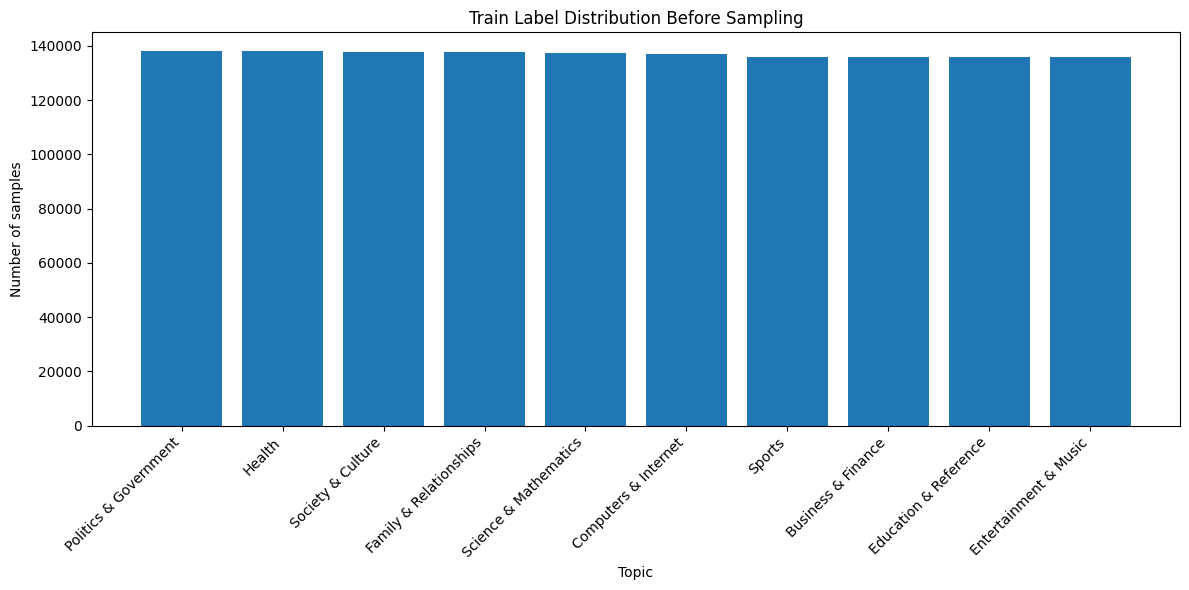

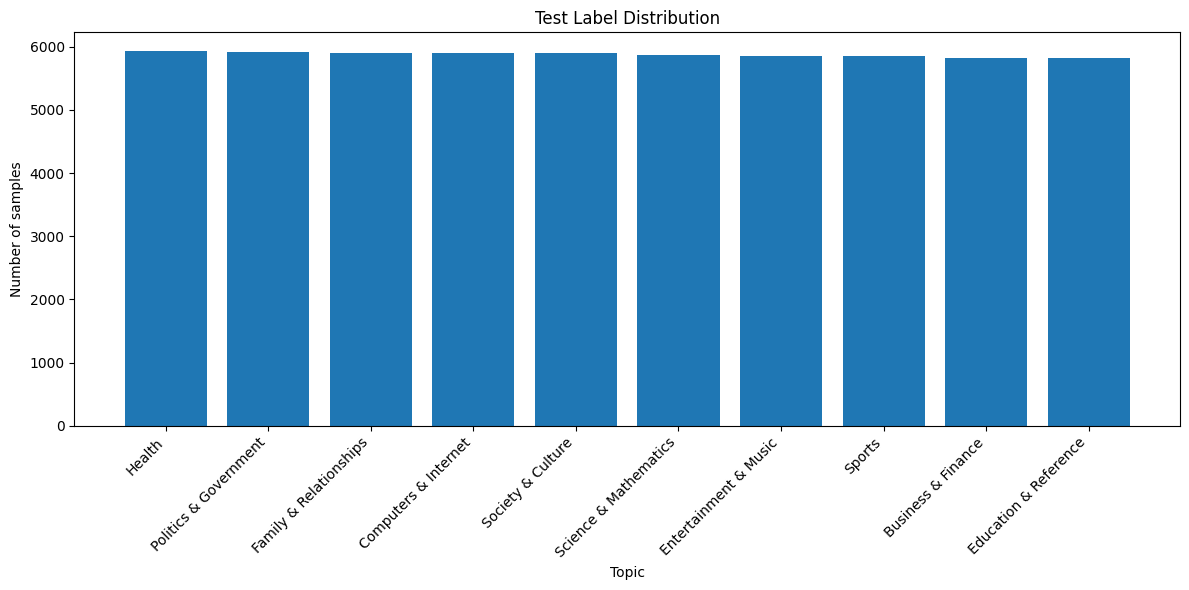

In [6]:
def plot_label_distribution(series, title, save_path=None):
    counts = series.value_counts().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(counts.index, counts.values)
    plt.title(title)
    plt.xlabel("Topic")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

plot_label_distribution(
    train_df["topic"],
    "Train Label Distribution Before Sampling",
    f"{FIG_DIR}/train_distribution_before_sampling.png"
)

plot_label_distribution(
    test_df["topic"],
    "Test Label Distribution",
    f"{FIG_DIR}/test_distribution.png"
)

## 7. Sample dữ liệu train nếu cần

Yahoo full rất lớn. Nếu `USE_ALL_DATA=False`, notebook sẽ lấy `SAMPLE_PER_TOPIC` dòng cho mỗi topic.

Vẫn lấy đủ 10 topic, chỉ giảm số dòng mỗi topic để Colab chạy ổn hơn.

Using sampled training data: 80000 samples/topic
Final train shape: (800000, 3)
Final test shape : (58742, 3)

Final train distribution:
topic
Education & Reference     80000
Entertainment & Music     80000
Health                    80000
Science & Mathematics     80000
Computers & Internet      80000
Sports                    80000
Family & Relationships    80000
Politics & Government     80000
Business & Finance        80000
Society & Culture         80000
Name: count, dtype: int64


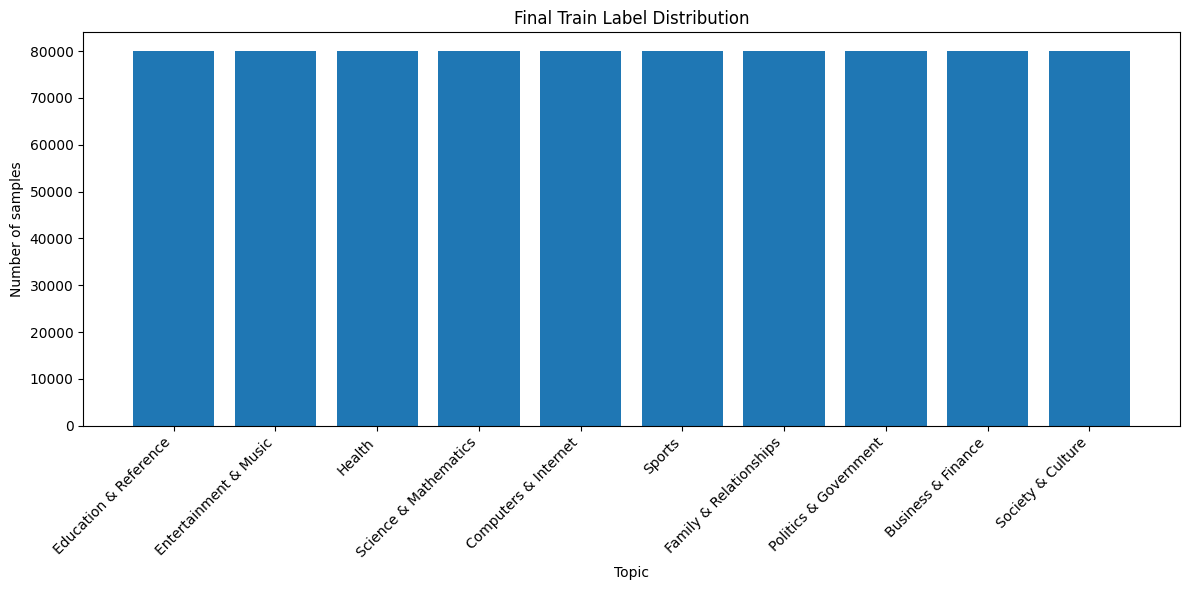

In [7]:
if USE_ALL_DATA:
    train_final = train_df.copy()
    print("Using ALL training data.")
else:
    train_final = (
        train_df
        .groupby("topic", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), SAMPLE_PER_TOPIC),
            random_state=RANDOM_STATE
        ))
        .reset_index(drop=True)
    )
    print(f"Using sampled training data: {SAMPLE_PER_TOPIC} samples/topic")

# Shuffle lại
train_final = train_final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_final = test_df.copy()

print("Final train shape:", train_final.shape)
print("Final test shape :", test_final.shape)

print("\nFinal train distribution:")
print(train_final["topic"].value_counts())

plot_label_distribution(
    train_final["topic"],
    "Final Train Label Distribution",
    f"{FIG_DIR}/final_train_distribution.png"
)

## 8. Train mô hình TF-IDF + LinearSVC

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

X_train = train_final["text"]
y_train = train_final["topic"]

X_test = test_final["text"]
y_test = test_final["topic"]

topic_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=150000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        dtype=np.float32
    )),
    ("clf", LinearSVC(
        C=1.5,
        class_weight="balanced",
        random_state=42
    ))
])

topic_model.fit(X_train, y_train)

print("Training done.")
print("Number of TF-IDF features:", len(topic_model.named_steps["tfidf"].get_feature_names_out()))
print("Classes:", topic_model.named_steps["clf"].classes_)

Training done.
Number of TF-IDF features: 150000
Classes: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']


## 9. Đánh giá model

In [9]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

y_pred = topic_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_summary = pd.DataFrame({
    "metric": ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"],
    "score": [acc, macro_precision, macro_recall, macro_f1, weighted_f1]
})

display(metrics_summary)

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T

display(report_df)

metrics_summary.to_csv(f"{REPORT_DIR}/metrics_summary.csv", index=False)
report_df.to_csv(f"{REPORT_DIR}/classification_report.csv", index=True)

print(classification_report(y_test, y_pred, zero_division=0))

,metric,score
0,accuracy,0.701900
1,macro_precision,0.696876
2,macro_recall,0.701424
3,macro_f1,0.698461
4,weighted_f1,0.698841


,precision,recall,f1-score,support
Business & Finance,0.563022,0.498281,0.528677,5818.0000
Computers & Internet,0.832300,0.865626,0.848636,5894.0000
Education & Reference,0.551280,0.492776,0.520389,5814.0000
Entertainment & Music,0.697796,0.708768,0.703239,5851.0000
Family & Relationships,0.685330,0.742083,0.712578,5905.0000
Health,0.742065,0.780607,0.760848,5930.0000
Politics & Government,0.736335,0.762202,0.749046,5921.0000
Science & Mathematics,0.696768,0.731333,0.713632,5866.0000
Society & Culture,0.584830,0.546920,0.565240,5893.0000
Sports,0.879030,0.885641,0.882323,5850.0000


                        precision    recall  f1-score   support

    Business & Finance       0.56      0.50      0.53      5818
  Computers & Internet       0.83      0.87      0.85      5894
 Education & Reference       0.55      0.49      0.52      5814
 Entertainment & Music       0.70      0.71      0.70      5851
Family & Relationships       0.69      0.74      0.71      5905
                Health       0.74      0.78      0.76      5930
 Politics & Government       0.74      0.76      0.75      5921
 Science & Mathematics       0.70      0.73      0.71      5866
     Society & Culture       0.58      0.55      0.57      5893
                Sports       0.88      0.89      0.88      5850

              accuracy                           0.70     58742
             macro avg       0.70      0.70      0.70     58742
          weighted avg       0.70      0.70      0.70     58742



## 10. Biểu đồ tổng quan metric

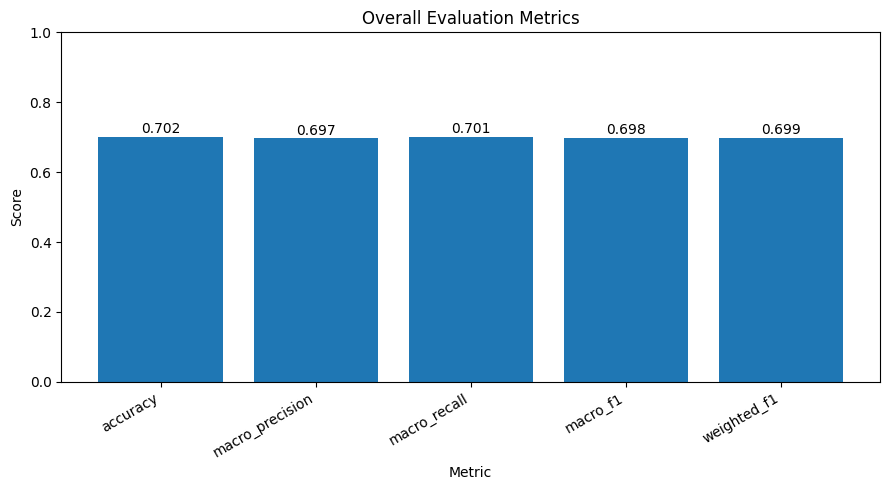

In [10]:
plt.figure(figsize=(9, 5))
plt.bar(metrics_summary["metric"], metrics_summary["score"])
plt.ylim(0, 1)
plt.title("Overall Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(metrics_summary["score"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/overall_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Biểu đồ Precision / Recall / F1 theo từng topic

,precision,recall,f1-score,support
Business & Finance,0.563022,0.498281,0.528677,5818.0
Computers & Internet,0.832300,0.865626,0.848636,5894.0
Education & Reference,0.551280,0.492776,0.520389,5814.0
Entertainment & Music,0.697796,0.708768,0.703239,5851.0
Family & Relationships,0.685330,0.742083,0.712578,5905.0
Health,0.742065,0.780607,0.760848,5930.0
Politics & Government,0.736335,0.762202,0.749046,5921.0
Science & Mathematics,0.696768,0.731333,0.713632,5866.0
Society & Culture,0.584830,0.546920,0.565240,5893.0
Sports,0.879030,0.885641,0.882323,5850.0


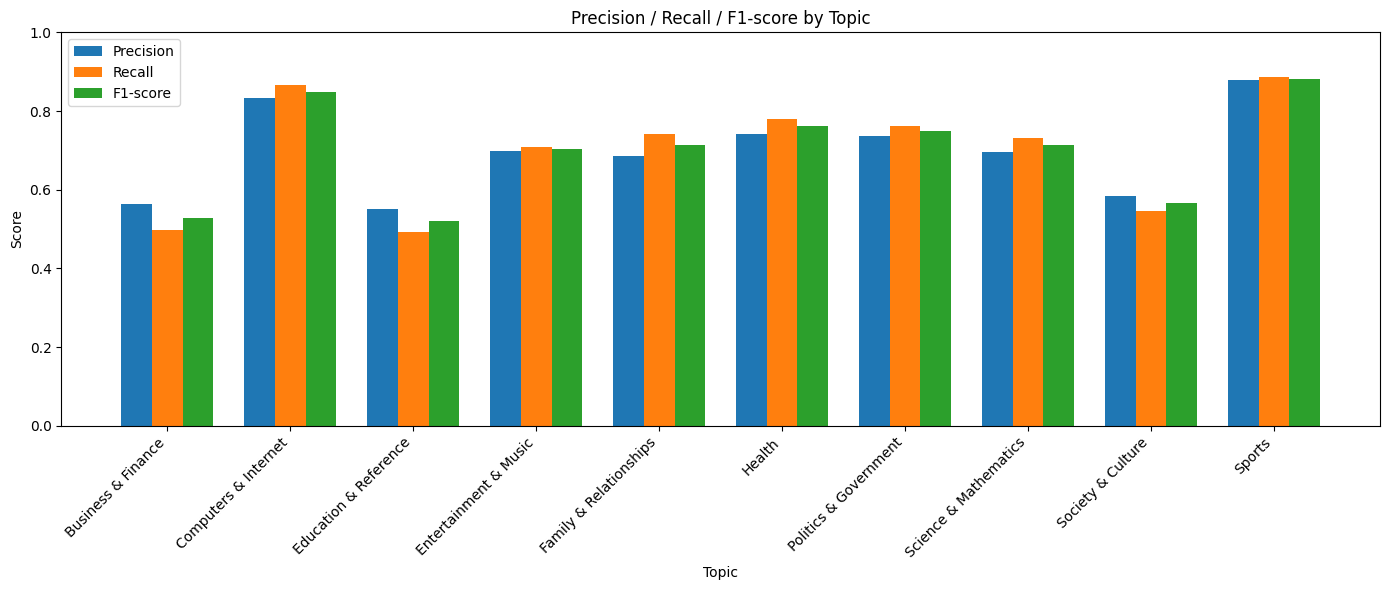

In [11]:
class_report_df = report_df.loc[
    [c for c in topic_model.named_steps["clf"].classes_ if c in report_df.index],
    ["precision", "recall", "f1-score", "support"]
].copy()

display(class_report_df)

x = np.arange(len(class_report_df.index))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, class_report_df["precision"], width, label="Precision")
plt.bar(x, class_report_df["recall"], width, label="Recall")
plt.bar(x + width, class_report_df["f1-score"], width, label="F1-score")

plt.ylim(0, 1)
plt.title("Precision / Recall / F1-score by Topic")
plt.xlabel("Topic")
plt.ylabel("Score")
plt.xticks(x, class_report_df.index, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/per_class_precision_recall_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Biểu đồ F1-score từng topic

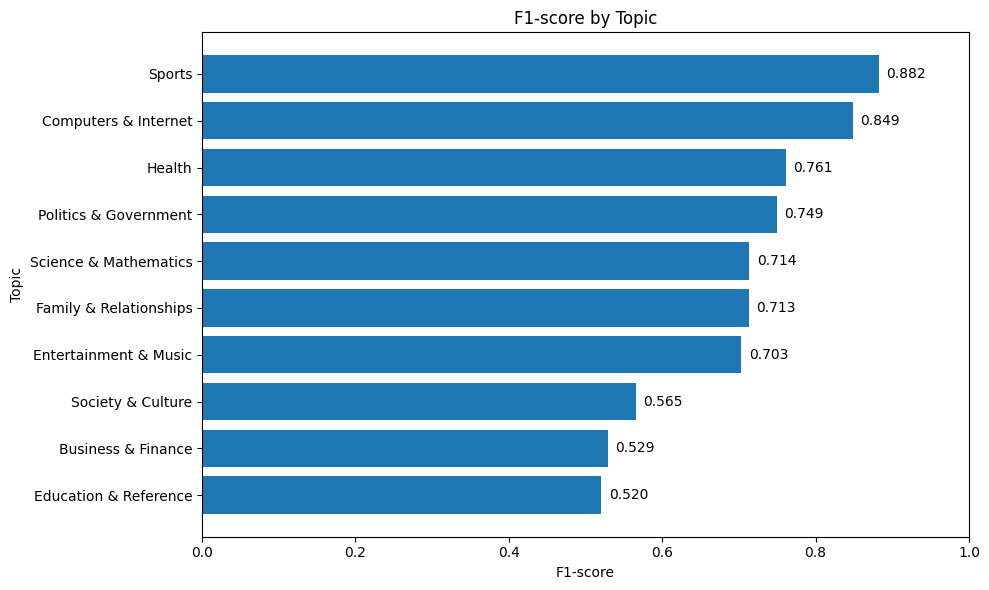

In [12]:
f1_sorted = class_report_df["f1-score"].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(f1_sorted.index, f1_sorted.values)
plt.xlim(0, 1)
plt.title("F1-score by Topic")
plt.xlabel("F1-score")
plt.ylabel("Topic")

for i, v in enumerate(f1_sorted.values):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/f1_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Confusion Matrix - Raw Count

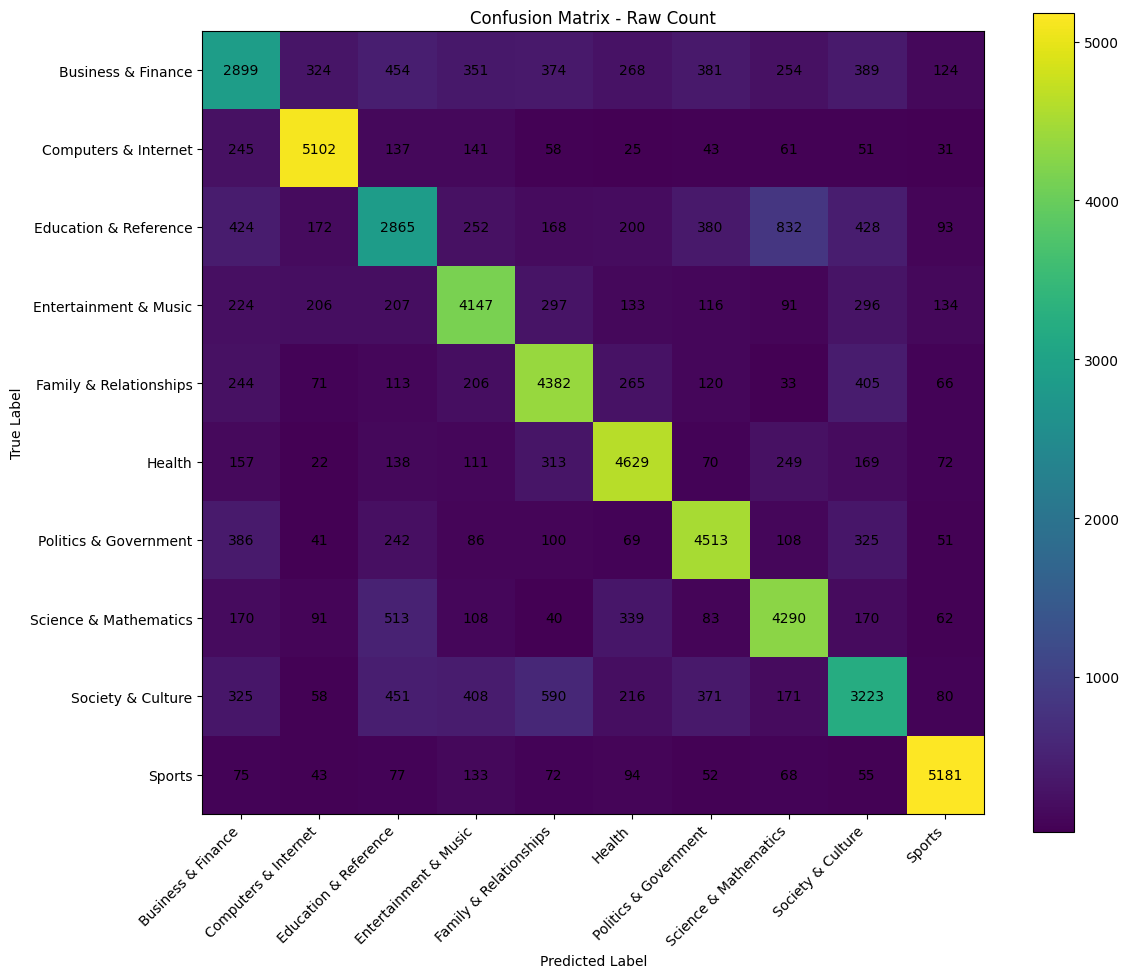

,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Business & Finance,2899,324,454,351,374,268,381,254,389,124
Computers & Internet,245,5102,137,141,58,25,43,61,51,31
Education & Reference,424,172,2865,252,168,200,380,832,428,93
Entertainment & Music,224,206,207,4147,297,133,116,91,296,134
Family & Relationships,244,71,113,206,4382,265,120,33,405,66
Health,157,22,138,111,313,4629,70,249,169,72
Politics & Government,386,41,242,86,100,69,4513,108,325,51
Science & Mathematics,170,91,513,108,40,339,83,4290,170,62
Society & Culture,325,58,451,408,590,216,371,171,3223,80
Sports,75,43,77,133,72,94,52,68,55,5181


In [13]:
labels = list(topic_model.named_steps["clf"].classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv(f"{REPORT_DIR}/confusion_matrix_raw.csv")

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Confusion Matrix - Raw Count")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        plt.text(j, i, str(value), ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix_raw.png", dpi=150, bbox_inches="tight")
plt.show()

display(cm_df)

## 14. Confusion Matrix - Normalized (%)

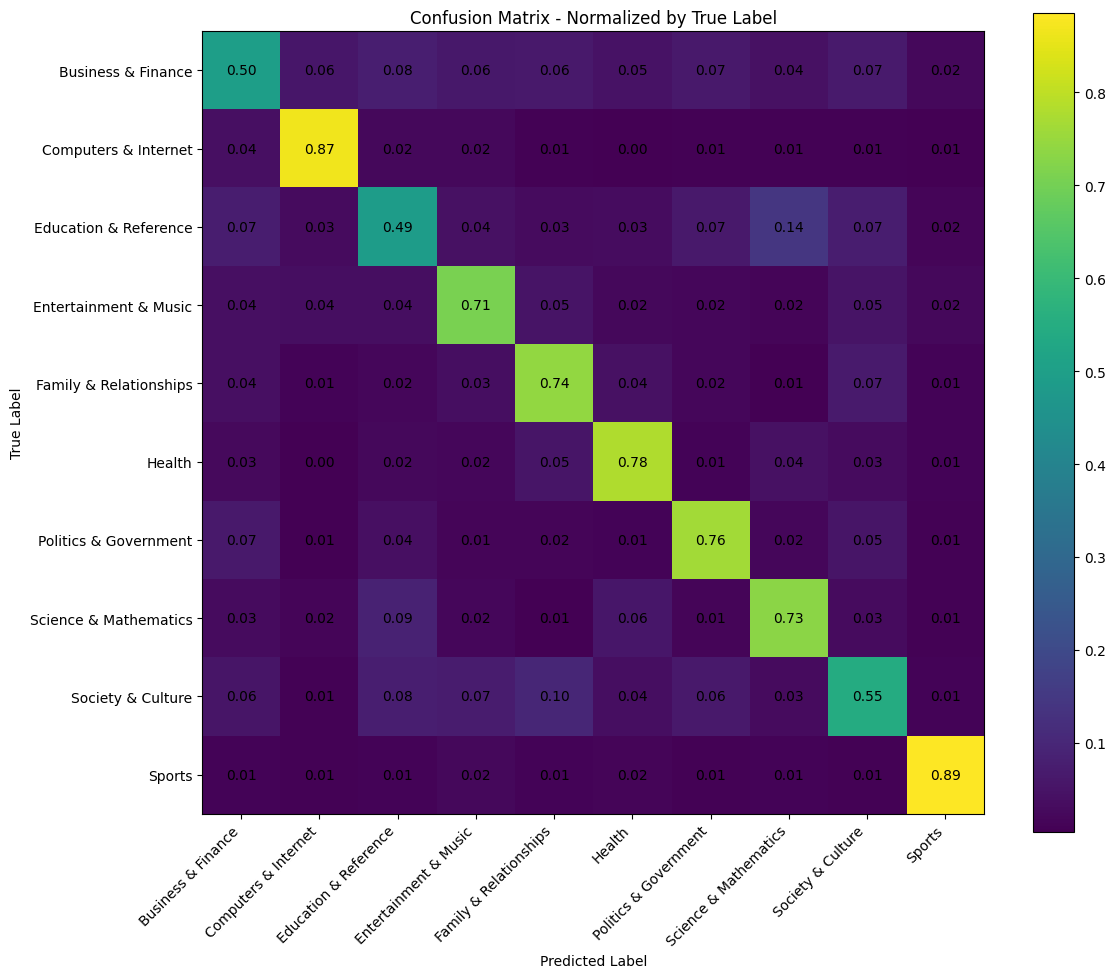

,Business & Finance,Computers & Internet,Education & Reference,Entertainment & Music,Family & Relationships,Health,Politics & Government,Science & Mathematics,Society & Culture,Sports
Business & Finance,0.498281,0.055689,0.078034,0.060330,0.064283,0.046064,0.065486,0.043658,0.066861,0.021313
Computers & Internet,0.041568,0.865626,0.023244,0.023923,0.009841,0.004242,0.007296,0.010350,0.008653,0.005260
Education & Reference,0.072927,0.029584,0.492776,0.043344,0.028896,0.034400,0.065359,0.143103,0.073615,0.015996
Entertainment & Music,0.038284,0.035208,0.035379,0.708768,0.050761,0.022731,0.019826,0.015553,0.050590,0.022902
Family & Relationships,0.041321,0.012024,0.019136,0.034886,0.742083,0.044877,0.020322,0.005588,0.068586,0.011177
Health,0.026476,0.003710,0.023272,0.018718,0.052782,0.780607,0.011804,0.041990,0.028499,0.012142
Politics & Government,0.065192,0.006925,0.040871,0.014525,0.016889,0.011653,0.762202,0.018240,0.054889,0.008613
Science & Mathematics,0.028981,0.015513,0.087453,0.018411,0.006819,0.057791,0.014149,0.731333,0.028981,0.010569
Society & Culture,0.055150,0.009842,0.076531,0.069235,0.100119,0.036654,0.062956,0.029017,0.546920,0.013575
Sports,0.012821,0.007350,0.013162,0.022735,0.012308,0.016068,0.008889,0.011624,0.009402,0.885641


In [14]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

cm_norm_df = pd.DataFrame(cm_norm, index=labels, columns=labels)
cm_norm_df.to_csv(f"{REPORT_DIR}/confusion_matrix_normalized.csv")

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm)
plt.title("Confusion Matrix - Normalized by True Label")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha="right")
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar()

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        value = cm_norm[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

display(cm_norm_df)

## 15. Xem các dòng dự đoán sai

In [15]:
errors_df = pd.DataFrame({
    "text": X_test.values,
    "true_topic": y_test.values,
    "pred_topic": y_pred
})

errors_df = errors_df[errors_df["true_topic"] != errors_df["pred_topic"]].copy()
errors_df["text_short"] = errors_df["text"].str.slice(0, 300)

print("Number of errors:", len(errors_df))
display(errors_df[["true_topic", "pred_topic", "text_short"]].head(30))

errors_df.to_csv(f"{REPORT_DIR}/prediction_errors.csv", index=False)

Number of errors: 17511


,true_topic,pred_topic,text_short
1,Science & Mathematics,Education & Reference,Why does Zebras have stripes? What is the purp...
4,Health,Family & Relationships,If your co-worker is guilty of unsanitary hygi...
5,Computers & Internet,Entertainment & Music,what is the best podcast to subscribe to? This...
6,Health,Business & Finance,What are the risks of alternative medicine? Th...
8,Science & Mathematics,Society & Culture,Do animals have a sense of humour? As an examp...
10,Entertainment & Music,Sports,Where abouts does Motanna Thompson who plays j...
11,Family & Relationships,Entertainment & Music,The website HotorNot? What do you think of tha...
12,Business & Finance,Computers & Internet,How do I take photos for e-commerce ? I need t...
16,Politics & Government,Science & Mathematics,motor vehicle agencys in central newjersey? rt...
18,Society & Culture,Science & Mathematics,"Why do they say, ""He bought the farm."" when so..."


## 16. Top từ/cụm từ quan trọng của từng topic

In [16]:
vectorizer = topic_model.named_steps["tfidf"]
clf = topic_model.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
classes = clf.classes_

top_terms_rows = []

for class_index, class_name in enumerate(classes):
    coefs = clf.coef_[class_index]
    top_idx = np.argsort(coefs)[::-1][:30]

    for rank, idx in enumerate(top_idx, start=1):
        top_terms_rows.append({
            "topic": class_name,
            "rank": rank,
            "term": feature_names[idx],
            "coef": coefs[idx]
        })

top_terms_df = pd.DataFrame(top_terms_rows)
top_terms_df.to_csv(f"{REPORT_DIR}/top_terms_by_topic.csv", index=False)

display(top_terms_df.head(60))

,topic,rank,term,coef
0,Business & Finance,1,technical analysis,3.323774
1,Business & Finance,2,backers,3.137996
2,Business & Finance,3,fishie,2.983144
3,Business & Finance,4,investing,2.882813
4,Business & Finance,5,interview tomorrow,2.702173
5,Business & Finance,6,target market,2.689062
6,Business & Finance,7,jagger,2.660951
7,Business & Finance,8,realtor,2.660573
8,Business & Finance,9,school doctor,2.650860
9,Business & Finance,10,forex,2.635005


## 17. Biểu đồ top terms cho từng topic

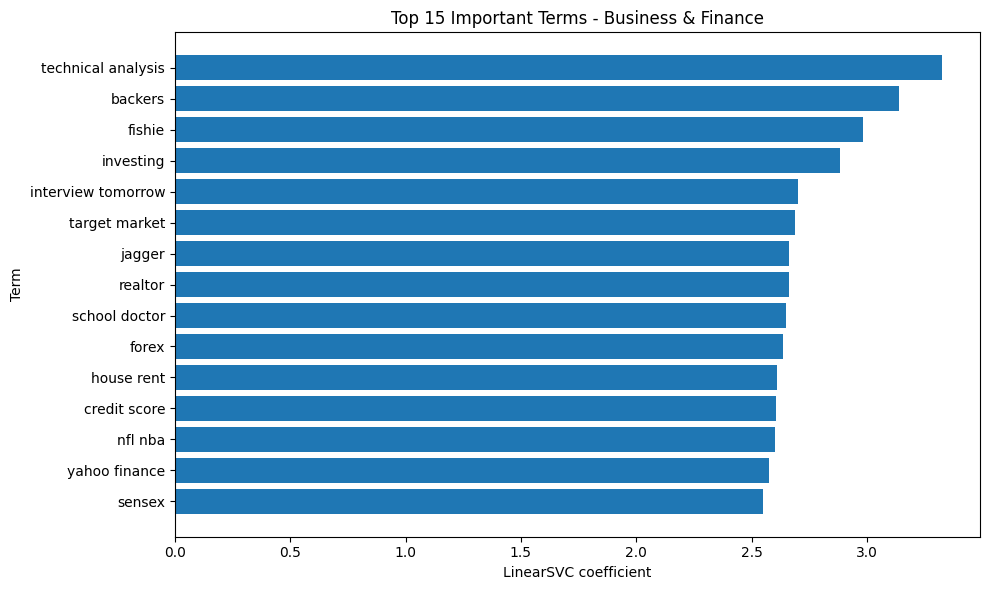

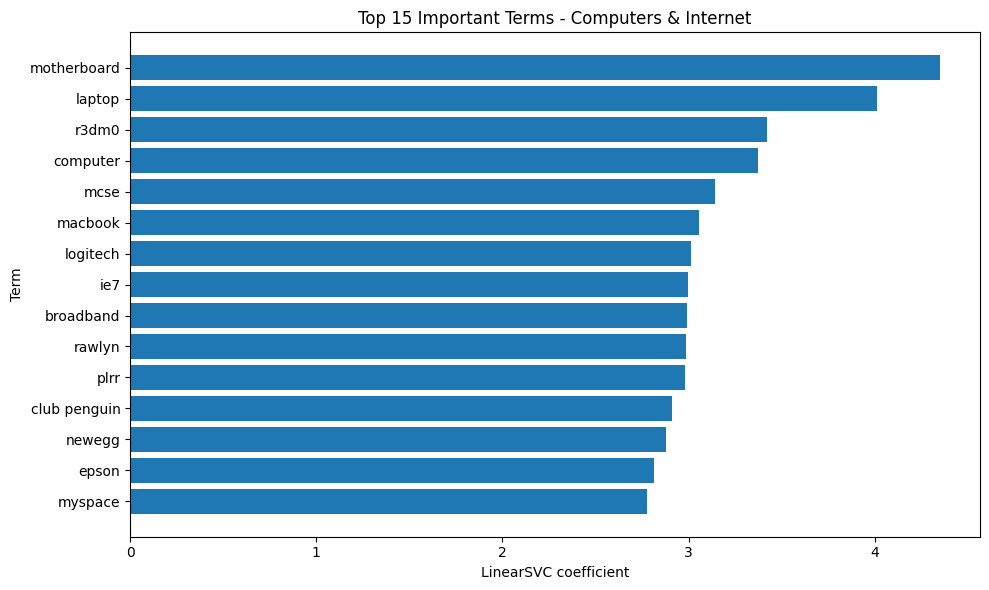

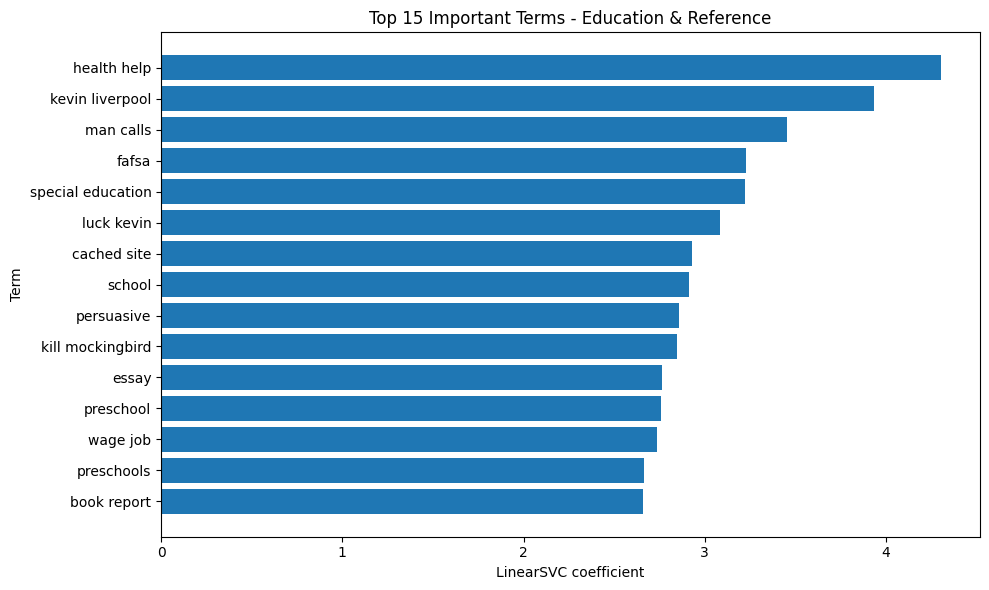

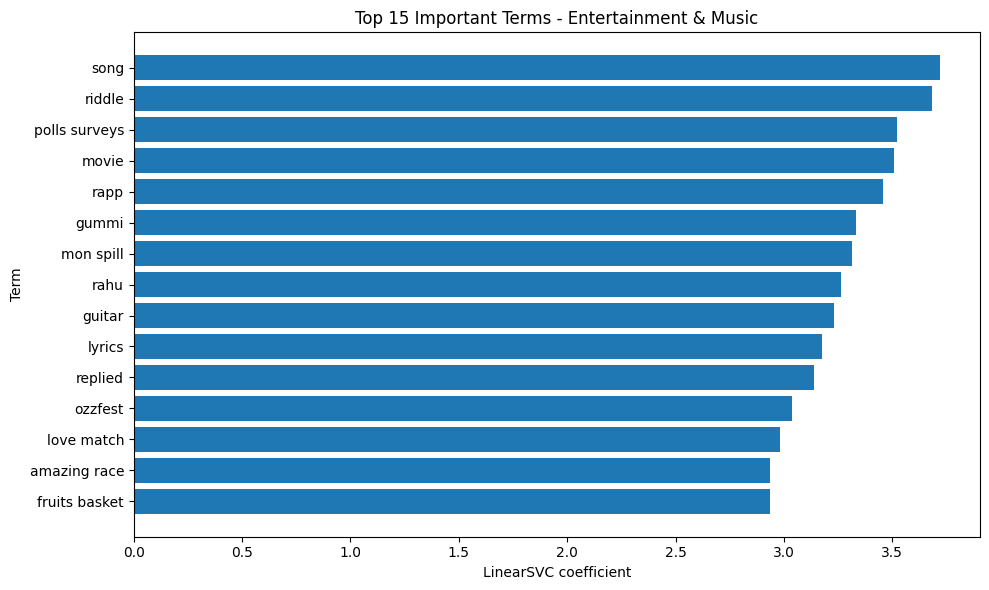

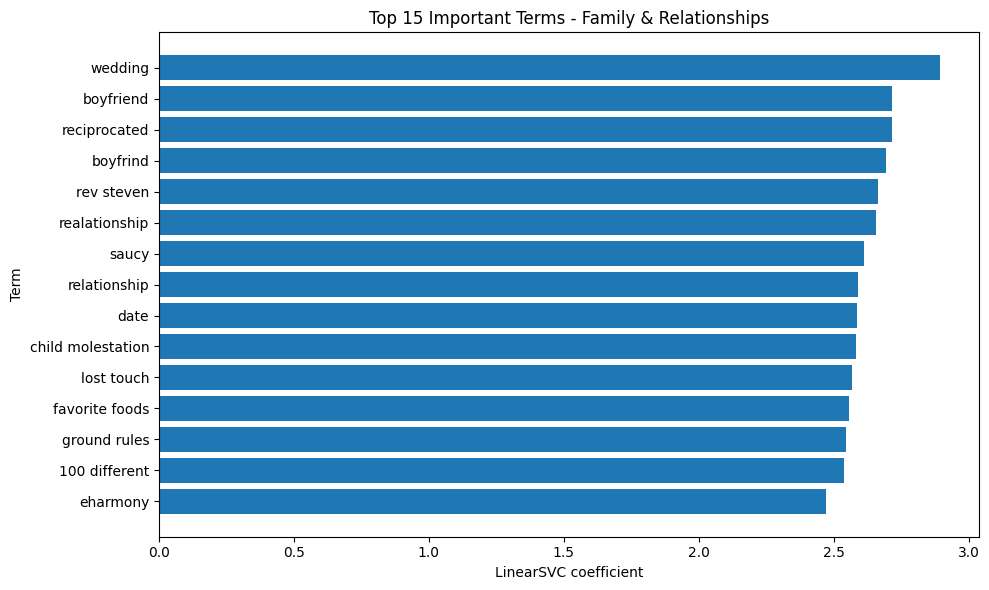

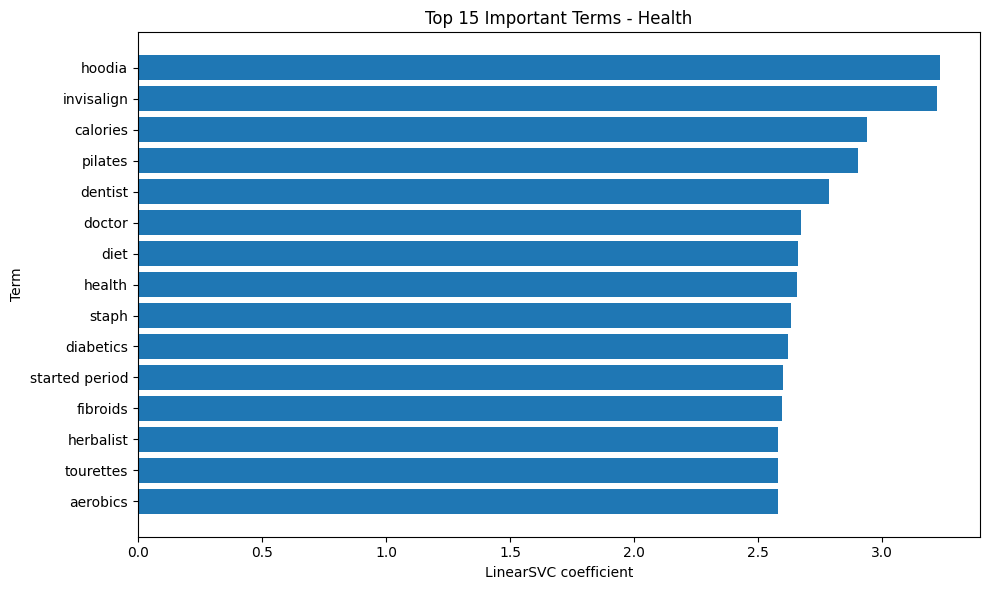

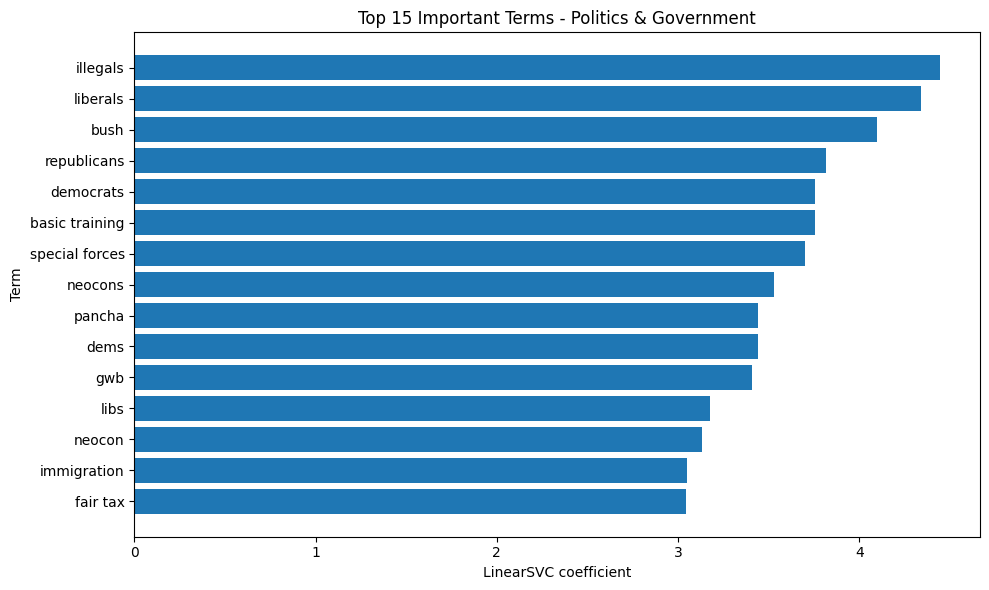

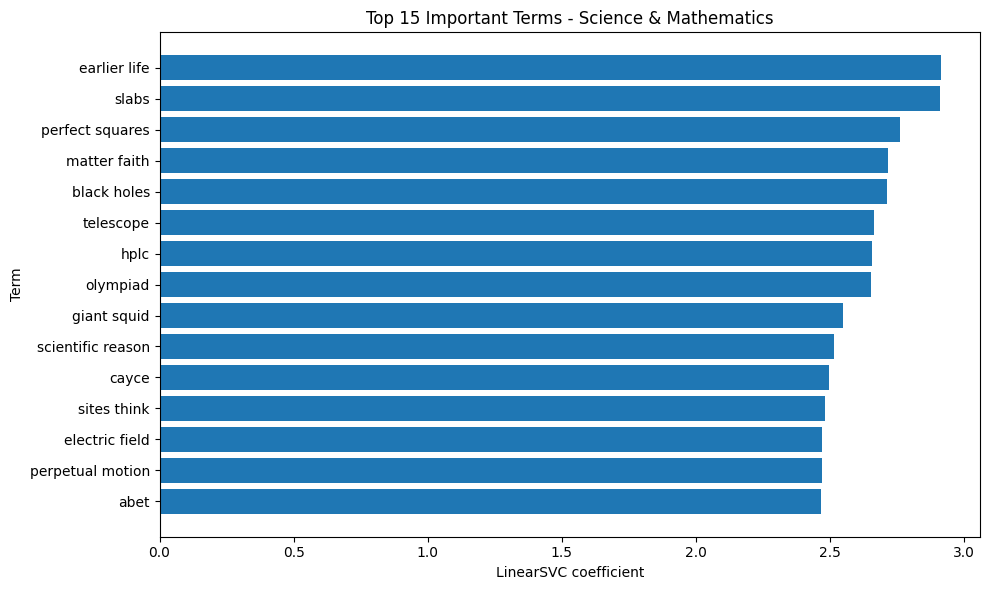

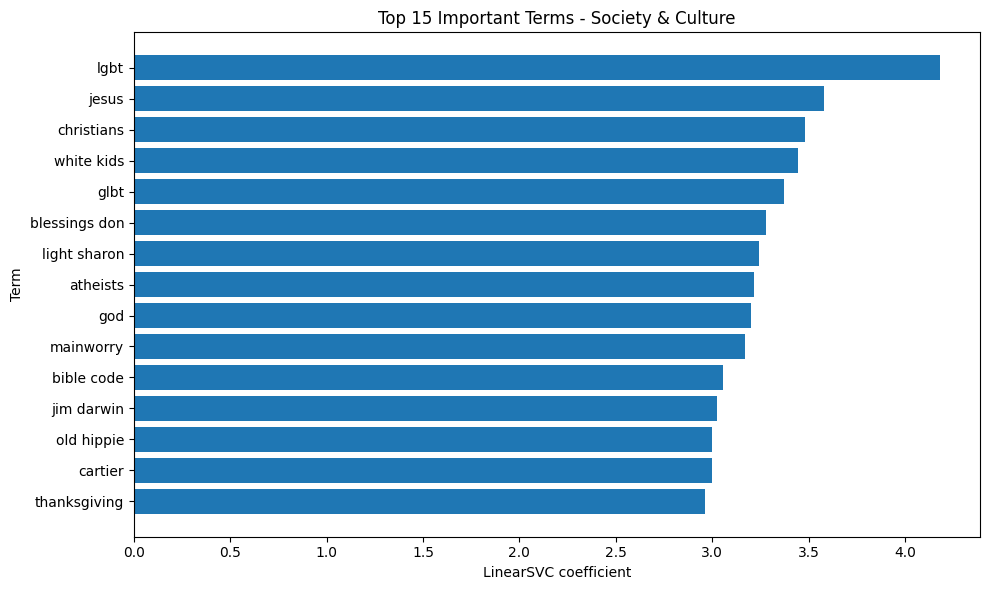

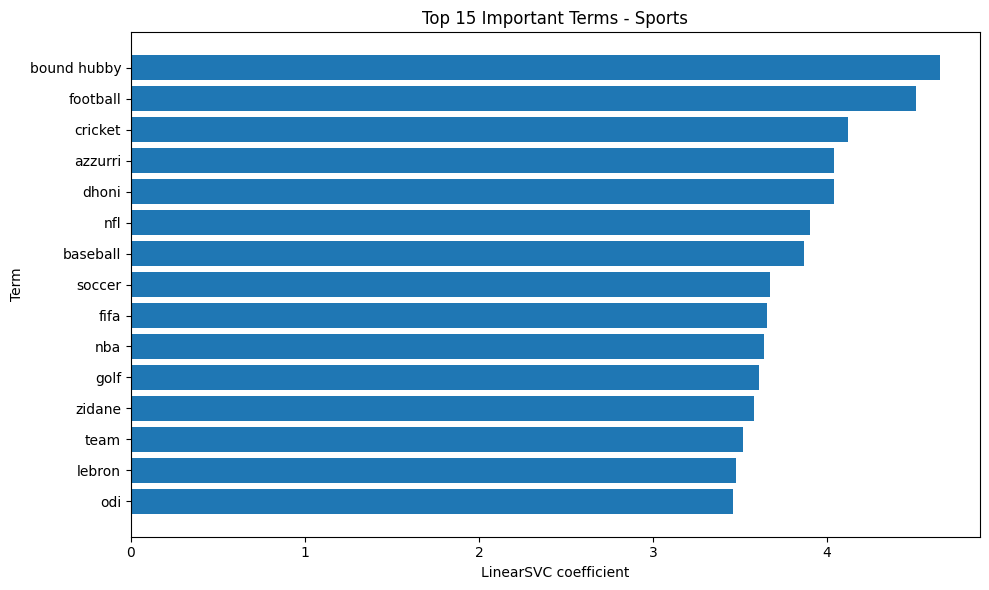

In [17]:
def plot_top_terms_for_topic(topic_name, top_n=15):
    sub = top_terms_df[top_terms_df["topic"] == topic_name].head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(sub["term"], sub["coef"])
    plt.title(f"Top {top_n} Important Terms - {topic_name}")
    plt.xlabel("LinearSVC coefficient")
    plt.ylabel("Term")
    plt.tight_layout()

    safe_name = re.sub(r"[^a-zA-Z0-9_]+", "_", topic_name)
    plt.savefig(f"{FIG_DIR}/top_terms_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

for topic_name in classes:
    plot_top_terms_for_topic(topic_name, top_n=15)

## 18. Lưu model, config, label list

In [18]:
MODEL_PATH = f"{MODEL_DIR}/yahoo_10topics_tfidf_linearsvc.joblib"
LABEL_PATH = f"{MODEL_DIR}/labels.txt"
CONFIG_PATH = f"{MODEL_DIR}/config.txt"

joblib.dump(topic_model, MODEL_PATH)

with open(LABEL_PATH, "w", encoding="utf-8") as f:
    for label in labels:
        f.write(label + "\n")

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    f.write(f"USE_ALL_DATA={USE_ALL_DATA}\n")
    f.write(f"SAMPLE_PER_TOPIC={SAMPLE_PER_TOPIC}\n")
    f.write(f"MAX_FEATURES={MAX_FEATURES}\n")
    f.write(f"NGRAM_RANGE={NGRAM_RANGE}\n")
    f.write(f"MIN_DF={MIN_DF}\n")
    f.write(f"MAX_DF={MAX_DF}\n")
    f.write(f"RANDOM_STATE={RANDOM_STATE}\n")
    f.write(f"Accuracy={acc}\n")
    f.write(f"Macro F1={macro_f1}\n")
    f.write(f"Weighted F1={weighted_f1}\n")

print("Saved model:", MODEL_PATH)
print("Saved labels:", LABEL_PATH)
print("Saved config:", CONFIG_PATH)
print("Reports:", REPORT_DIR)
print("Figures:", FIG_DIR)

Saved model: /content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All/model/yahoo_10topics_tfidf_linearsvc.joblib
Saved labels: /content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All/model/labels.txt
Saved config: /content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All/model/config.txt
Reports: /content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All/reports
Figures: /content/drive/MyDrive/TrainTopic/Yahoo_Topic_Model_All/figures


## 19. Load model và predict một đoạn text

In [19]:
loaded_model = joblib.load(MODEL_PATH)

sample_text = (
    "Water is important for the human body. It helps regulate temperature, "
    "supports the brain, protects joints, and prevents dehydration. "
    "Drinking enough water can improve energy, mood, and overall health."
)

pred_topic = loaded_model.predict([sample_text])[0]
print("Predicted topic:", pred_topic)

Predicted topic: Science & Mathematics


## 20. Predict kèm top điểm topic

In [20]:
def predict_topic_with_scores(text, model, top_k=5):
    scores = model.decision_function([text])

    if scores.ndim == 1:
        scores = scores.reshape(1, -1)

    scores = scores[0]
    classes = model.named_steps["clf"].classes_

    ranking = sorted(
        zip(classes, scores),
        key=lambda x: x[1],
        reverse=True
    )

    return pd.DataFrame(ranking[:top_k], columns=["topic", "decision_score"])

predict_topic_with_scores(sample_text, loaded_model, top_k=5)

,topic,decision_score
0,Science & Mathematics,0.015452
1,Health,-0.144628
2,Education & Reference,-0.975899
3,Business & Finance,-1.140130
4,Politics & Government,-1.341997


## 21. Predict transcript dài bằng cách chia chunk rồi vote

In [21]:
def split_long_text(text, chunk_size=300, overlap=50):
    words = str(text).split()

    if len(words) <= chunk_size:
        return [str(text)]

    chunks = []
    step = max(1, chunk_size - overlap)

    for i in range(0, len(words), step):
        chunk = " ".join(words[i:i + chunk_size])
        if len(chunk.split()) >= 30:
            chunks.append(chunk)

    return chunks

def predict_long_topic(text, model, chunk_size=300, overlap=50):
    chunks = split_long_text(text, chunk_size=chunk_size, overlap=overlap)

    chunk_preds = model.predict(chunks)
    topic_counts = pd.Series(chunk_preds).value_counts()

    main_topic = topic_counts.idxmax()

    chunk_result_df = pd.DataFrame({
        "chunk_id": range(1, len(chunks) + 1),
        "chunk_text": chunks,
        "pred_topic": chunk_preds
    })

    return {
        "main_topic": main_topic,
        "topic_counts": topic_counts,
        "chunk_results": chunk_result_df
    }

long_result = predict_long_topic(sample_text, loaded_model)

print("Main topic:", long_result["main_topic"])
display(long_result["topic_counts"].to_frame("count"))
display(long_result["chunk_results"])

Main topic: Science & Mathematics


,count
Science & Mathematics,1


,chunk_id,chunk_text,pred_topic
0,1,Water is important for the human body. It help...,Science & Mathematics


## 22. Biểu đồ topic vote cho transcript dài

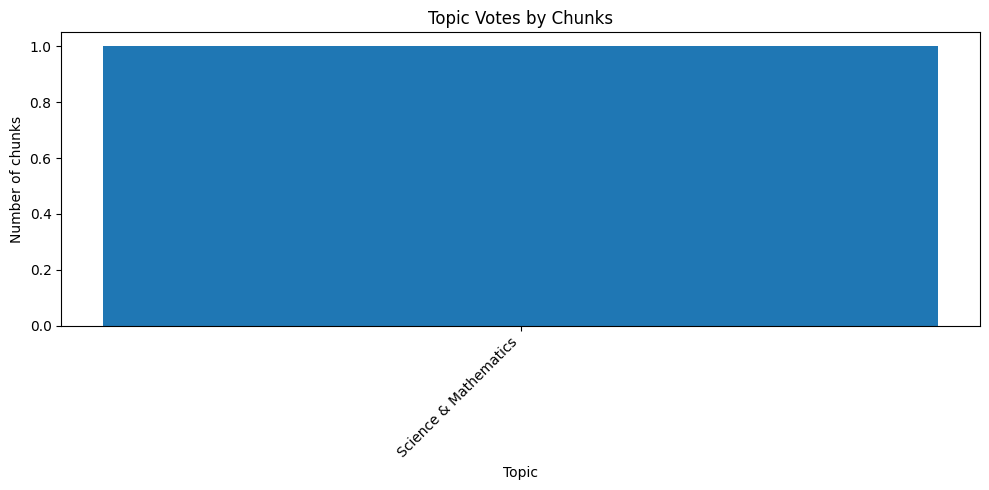

In [22]:
def plot_long_text_topic_votes(topic_counts, title="Topic Votes by Chunks"):
    plt.figure(figsize=(10, 5))
    plt.bar(topic_counts.index, topic_counts.values)
    plt.title(title)
    plt.xlabel("Topic")
    plt.ylabel("Number of chunks")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_long_text_topic_votes(long_result["topic_counts"])

## 23. Lấy từ vựng / keywords quan trọng từ một đoạn text

In [23]:
def extract_keywords_from_text(text, model, top_n=20, only_single_words=False):
    vectorizer = model.named_steps["tfidf"]

    X = vectorizer.transform([text])
    feature_names = np.array(vectorizer.get_feature_names_out())
    scores = X.toarray().ravel()

    sorted_idx = scores.argsort()[::-1]

    results = []

    for idx in sorted_idx:
        score = scores[idx]

        if score <= 0:
            break

        term = feature_names[idx]

        if only_single_words and " " in term:
            continue

        if len(term) <= 2:
            continue

        if re.fullmatch(r"\d+", term):
            continue

        results.append({
            "term": term,
            "tfidf_score": float(score)
        })

        if len(results) >= top_n:
            break

    return pd.DataFrame(results)

keywords_df = extract_keywords_from_text(sample_text, loaded_model, top_n=20)
display(keywords_df)

,term,tfidf_score
0,helps regulate,0.304181
1,water important,0.297255
2,overall health,0.274702
3,dehydration,0.239716
4,drinking water,0.232247
5,protects,0.224045
6,regulate,0.223703
7,joints,0.220651
8,prevents,0.219207
9,water,0.216755


## 24. Sinh câu hỏi từ vựng đơn giản từ keywords

In [24]:
def generate_vocab_questions(text, model, top_n=5):
    topic = model.predict([text])[0]
    keywords = extract_keywords_from_text(text, model, top_n=top_n)

    questions = []

    for i, row in keywords.iterrows():
        term = row["term"]

        questions.append({
            "topic": topic,
            "vocab": term,
            "question_type": "meaning",
            "question": f'What does "{term}" mean in this text?',
            "answer_hint": "Answer based on the context of the passage."
        })

        questions.append({
            "topic": topic,
            "vocab": term,
            "question_type": "context",
            "question": f'Find the sentence or idea in the text that helps explain "{term}".',
            "answer_hint": "Look around the word in the passage."
        })

    return pd.DataFrame(questions)

vocab_questions_df = generate_vocab_questions(sample_text, loaded_model, top_n=5)
display(vocab_questions_df)

,topic,vocab,question_type,question,answer_hint
0,Science & Mathematics,helps regulate,meaning,"What does ""helps regulate"" mean in this text?",Answer based on the context of the passage.
1,Science & Mathematics,helps regulate,context,Find the sentence or idea in the text that hel...,Look around the word in the passage.
2,Science & Mathematics,water important,meaning,"What does ""water important"" mean in this text?",Answer based on the context of the passage.
3,Science & Mathematics,water important,context,Find the sentence or idea in the text that hel...,Look around the word in the passage.
4,Science & Mathematics,overall health,meaning,"What does ""overall health"" mean in this text?",Answer based on the context of the passage.
5,Science & Mathematics,overall health,context,Find the sentence or idea in the text that hel...,Look around the word in the passage.
6,Science & Mathematics,dehydration,meaning,"What does ""dehydration"" mean in this text?",Answer based on the context of the passage.
7,Science & Mathematics,dehydration,context,Find the sentence or idea in the text that hel...,Look around the word in the passage.
8,Science & Mathematics,drinking water,meaning,"What does ""drinking water"" mean in this text?",Answer based on the context of the passage.
9,Science & Mathematics,drinking water,context,Find the sentence or idea in the text that hel...,Look around the word in the passage.


## 25. Lưu kết quả inference mẫu

In [25]:
keywords_df.to_csv(f"{REPORT_DIR}/sample_keywords.csv", index=False)
vocab_questions_df.to_csv(f"{REPORT_DIR}/sample_vocab_questions.csv", index=False)

print("Saved sample keyword and vocabulary question files.")

Saved sample keyword and vocabulary question files.


# Ghi chú sử dụng

Sau khi chạy xong, bạn sẽ có:

- Model: `Yahoo_Topic_Model_All/model/yahoo_10topics_tfidf_linearsvc.joblib`
- Report CSV: `Yahoo_Topic_Model_All/reports/`
- Biểu đồ PNG: `Yahoo_Topic_Model_All/figures/`

Nếu Colab bị crash RAM:
1. Giảm `SAMPLE_PER_TOPIC = 10000` hoặc `20000`
2. Giảm `MAX_FEATURES = 30000`
3. Đổi `NGRAM_RANGE = (1, 1)`

Nếu muốn train full 1.4 triệu dòng:
```python
USE_ALL_DATA = True
```
nhưng cần RAM đủ mạnh.